In [170]:
import math, sys, os, time
import struct
from importlib import reload
from tqdm import tqdm
import time
import datetime
from pathlib import Path

# Third party libs
import pyvisa
import joblib
import numpy as np
import scipy
import matplotlib.pylab as plt
import h5py

# Current folder
import helper_visa as vs
import helper_fft
import user_io.IO_rigol as uio
import record
reload(record)
reload(helper_fft)
reload(uio)

<module 'user_io.IO_rigol' from '/mnt/c/Users/Tom/OneDrive/Documents/JupyterNotebooks/CDMS/VisaScope/SpecExplorer/user_io/IO_rigol.py'>

# Device Setting

In [141]:
## Address Examples
# address = None
address = "TCPIP::192.168.1.171::INSTR"
# address = "USB0::0xF4EC::0x1305::SSA3PCEX6R0308::INSTR"

device = vs.connect(address = address, timeout=10_000, idn=False) # set 10 second timeout

Connected to VISA [TCPIP::192.168.1.171::INSTR]:  RIGOL TECHNOLOGIES,DHO924,DHO9A250009316,00.01.05



# Acquisation setting

In [73]:
CHANNELS = [1,2,3]
LENGTH = 1_000_000
DECIMATION = 10 # Down sampling factor, has to be a positive int. Set to 1 if not downsampling

SAVE = True
SAVE_DIR = r'/home/tomren/home/Downloads/temp/'
SAVE_FILENAME_PATTERN = "%Y%m%d_%H%M%S"

# Example  to run the acquisation once
rawdata, time_series = uio.read_waveform(device, read_channel=CHANNELS, acquire_length=LENGTH, calibrate=True, trigger_timeout=15)

### Some functions

In [171]:
def get_trace():
    rawdata, time_series = uio.read_waveform(device, read_channel=CHANNELS, acquire_length=LENGTH, calibrate=True, trigger_timeout=15)
    # rawdata = {"1":np.ones(1000000)}  
    ts = time.time()
    metadata = {"sampling_frequency": 1/(time_series[1] - time_series[0])}
    if DECIMATION>1:
        for ch in rawdata:
            rawdata[ch] = scipy.signal.decimate(rawdata[ch], DECIMATION)
        metadata["sampling_frequency"] = metadata["sampling_frequency"]/DECIMATION
    return rawdata, ts, metadata
    
def get_filename():
    now = datetime.datetime.now().strftime(SAVE_FILENAME_PATTERN)
    new_folder = SAVE_DIR + f"{now}/"
    os.makedirs(new_folder, exist_ok=True)
    return f"{new_folder}/{now}.hdf5"

def process_traces(filename, window=None):
    """
    window:  None or string, one of ["hann", "hamming", ...] that's supported by scipy.signal.get_window()
        window function for FFT. Use window function for less spectral leakage, especially for low frequency region. 
    """
    filename_new = os.path.splitext(filename)[0]+"_processed.joblib"
    psds = {}
    spectrogram = {}
    
    with h5py.File(filename, "r") as f:
        # List top-level keys
        print("Top level groups:", list(f.keys()))
    
        # Read timestamps
        timestamps = f["/timestamps"][:]
        print("timestamps shape:", timestamps.shape)
    
        # Read waveform channels
        waveforms_group = f["/waveforms"]
        channel_names = list(waveforms_group.keys())
        print("Channels:", channel_names)
    
        # Get sampling frequency
        sampling_freq = f["trace_meta"][list(f["trace_meta"].keys())[0]].attrs["sampling_frequency"]
        print(f"Sampling freq: {sampling_freq:.0f}")
        
        # Get the shape of data
        for ch in channel_names:
            data = waveforms_group[ch][:]
            print(f"{ch} shape:", data.shape)
            n_events = data.shape[0]
            trace_len = data.shape[1]
            psds[ch] = np.zeros(trace_len//2+1)
    
        
        # Instantiate spectrograms
        spectrogram_insts = {channel: helper_fft.LogSpectrogram(trace_len, bins=4096, fs=1) for channel in channel_names}
    
        # Main
        for channel in channel_names:
            for ievent in range((n_events)):
                waveform = waveforms_group[channel][ievent]   # shape (N_records, N_points)

                if window is not None:
                    W = scipy.signal.get_window(window, len(waveform))
                    U = np.mean(W**2)          # power correction factor
                    waveform = waveform*W / U
                
                waveform_fft_pwr = np.abs(np.fft.rfft(waveform))**2
                psds[channel] += waveform_fft_pwr
                spectrogram_insts[channel].add(waveform_fft_pwr)
    
            psds[channel] = psds[channel]/n_events/sampling_freq
            psd_freq = np.fft.rfftfreq(trace_len) * sampling_freq
            spectrogram_freq, spectrogram[channel] = spectrogram_insts[channel].get_data()
            spectrogram_freq = spectrogram_freq * sampling_freq
            spectrogram[channel] = spectrogram[channel]/sampling_freq
    
    
    data_save = {"psd_freq": psd_freq,
                "psds": psds,
                "spectrogram_freq":spectrogram_freq,
                "spectrogram":spectrogram}
    
    joblib.dump(data_save, filename_new)
    print("PSD and spectrogram saved:", filename_new)
    return data_save

# Run Acquisation

In [ ]:
# 200 traces is roughly 2GB on disk: 200* 1Msamples * 3channels * 4Byte/sample
NUM_TRACES = 200

record.record_traces_dict_to_hdf5(get_filename(), 
                             get_trace, 
                             max_traces=NUM_TRACES,
                             flush_every_traces=5,       # flush to disk every 5 traces
                             flush_every_s=10.0,         # or at least every 10 seconds
                             chunk_traces=1,             # one trace per chunk is common for 1M-point traces
                             file_attributes={
                                "instrument": "Siglent",
                                "channels": list(rawdata.keys()),
                                "points_per_trace": LENGTH,
                                
                              },   
                            )

File created: /home/tomren/home/Downloads/temp/20260305_153803//20260305_153803.hdf5


# Run processing

process_traces() function calculate the PSD and spectrogram of each channel.   
both PSD and spectrogram has unit of V^2/Hz

In [173]:
series = "20260305_153803"
filename_raw = f"{SAVE_DIR}/{series}//{series}.hdf5"
filename_processed = f"{SAVE_DIR}/{series}//{series}_processed.joblib"
process_traces(filename_raw, window = "hann");

# Load processed results and make plots

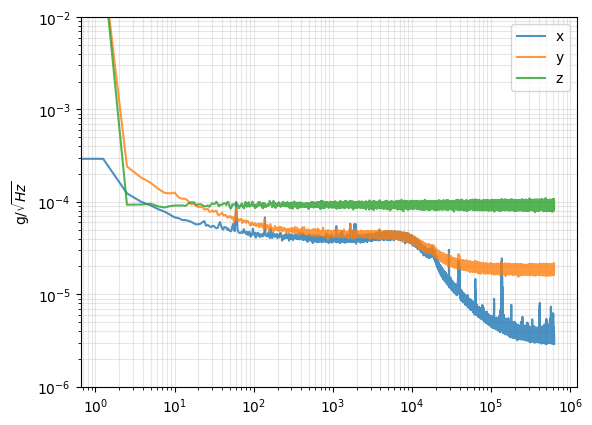

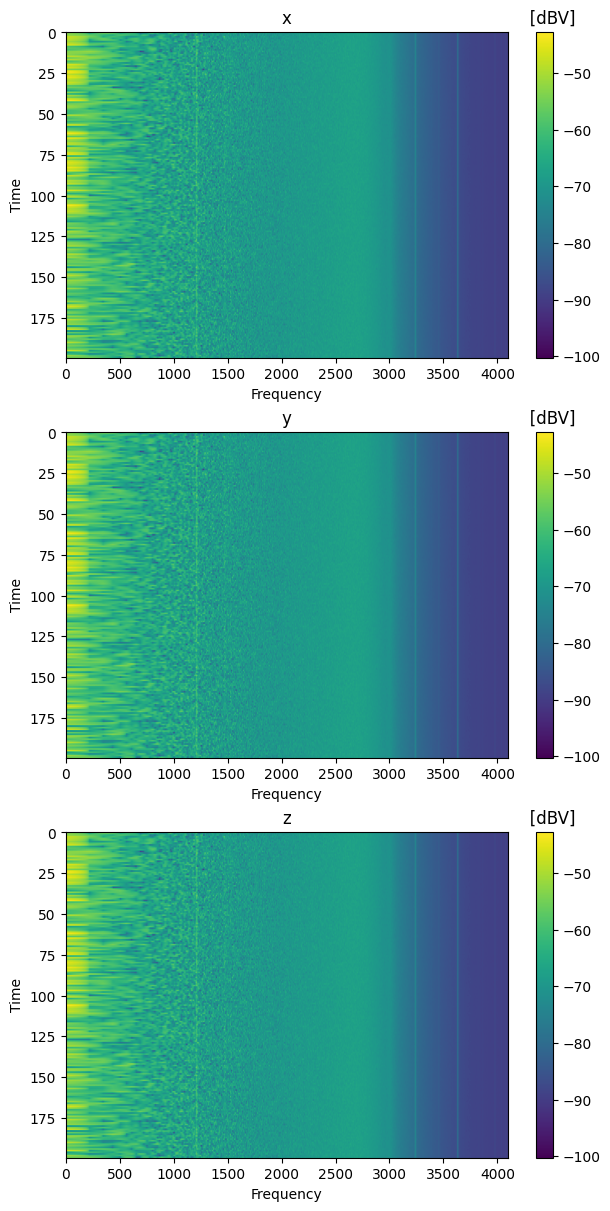

In [184]:
data = joblib.load(filename_processed)

labels = {'1':"x", '2':"y", '3':"z"}

for channel in ['1', '2', '3']:
    plt.loglog(data["psd_freq"], np.sqrt(data["psds"][channel])*0.1, label=labels[channel], alpha=0.8)
plt.ylabel(r"g/$\sqrt{Hz}$")
plt.ylim(1e-6,1e-2)
plt.grid(which="both", alpha=0.3)
plt.legend()
plt.show()


# Spectrogram 
fig, axs = plt.subplots(3,1,figsize=(6,12), constrained_layout=True)

### NEED TO FIX THE AXIS TICKS
# the frequencies of each bin is saved in data["spectrogram_freq"]

for i,channel in enumerate(['1', '2', '3']):
    im = axs[i].imshow(10*np.log10(data["spectrogram"]["1"]), aspect="auto")
    cbar = fig.colorbar(im, ax=axs[i])
    cbar.ax.set_title("   [dBV]", pad=6)
    axs[i].set_title(labels[channel])
    axs[i].set_xlabel("Frequency")
    axs[i].set_ylabel("Time")
plt.show()